# Tópicos, Sentimiento y ABSA en Encuestas Universitarias

**Proyecto:** Capstone NLP — MINE009 · **Módulo:** `Mod_Bertopic.py` (MVP 2)

---

## Por qué existe esta versión

La primera corrida sobre el corpus real dio un resultado inservible:

| Síntoma | Cifra |
|---|---|
| Tópicos | **136** — ilegible en un informe |
| Outliers | **40,1%** — cuatro de cada diez opiniones sin clasificar |
| "Corpus descartado" | **65,1%** — aparentemente se perdían dos tercios |

Al revisarlo resultaron ser **tres problemas independientes**, y sólo dos
eran culpa del modelo.

### Problema 1 — El 65% "descartado" nunca fue una pérdida

La pregunta abierta es **opcional**. La mayoría de esas filas son **celdas
vacías**: gente que respondió la parte cuantitativa y no escribió comentario.
Reportarlas como "descartadas" hace parecer que el modelo tira datos cuando
en realidad está midiendo la **tasa de respuesta** del instrumento.

Esta versión desglosa el descarte en VACÍA / RUIDO / CORTA y calcula los
porcentajes sobre respuestas **contestadas**, no sobre filas del archivo.

### Problema 2 — `min_topic_size` en escala absoluta

`min_topic_size=25` sobre 19.989 documentos únicos es el **0,125% del
corpus**, y admite hasta 800 tópicos. No era un valor agresivo: era un valor
sin escala. Ahora se expresa como **fracción del corpus**.

### Problema 3 — `min_samples` demasiado alto

Con `min_cluster_size=25` y `min_samples=10` el ratio es **0,40**. HDBSCAN se
vuelve tan conservador que manda el 40% de los documentos a outlier. La regla
práctica está cerca de **0,05**. Ahora se deriva solo y el módulo avisa si se
pasa de 0,20.

### Y lo que faltaba: una forma de encontrar los valores

Se añade `GridSearchTopicos`, una búsqueda por etapas que prueba decenas de
combinaciones contra **criterios de negocio explícitos** — no coherencia.

---

## El pipeline

```
   data/Corpus Ejemplo PLN.xlsx  ·  5 encuestas
                    │
      ┌─────────────┴──────────────┐
 texto _clean                texto ORIGINAL
 (sin tildes)                (con tildes)
      │                            │
 ┌────▼─────┐                ┌─────▼──────┐
 │EMBEDDINGS│◄── compartido ─│SEGMENTACIÓN│
 └────┬─────┘                │ cláusulas  │
      │                      └─────┬──────┘
 ┌────▼─────┐  384→5 dims          │
 │   UMAP   │                ┌─────▼──────┐
 └────┬─────┘                │SENTIMIENTO │
 ┌────▼─────┐                │POS/NEU/NEG │
 │ HDBSCAN  │                └─────┬──────┘
 └────┬─────┘                      │
 ┌────▼──────────────┐             │
 │ c-TF-IDF          │             │
 │ ★ stopwords AQUÍ ★│             │
 └────┬──────────────┘             │
      └──────────┬─────────────────┘
                 ▼
      ABSA: aspecto × polaridad
```

## Paso 0 — Entorno

**Qué hace:** carga librerías, fija la estética de las gráficas y localiza la
raíz del proyecto subiendo hasta encontrar `pyproject.toml`.

**Por qué:** el kernel de VS Code arranca desde directorios distintos según
cómo se abra el cuaderno. Buscar la raíz por marcador evita que las rutas se
rompan según quién ejecute.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*n_jobs value.*")

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.width", 175)

AZUL, NARANJA, VERDE, MORADO, ROJO, GRIS = (
    "#2c6fbb", "#c8811d", "#3d8b64", "#7a5195", "#c1453c", "#b8bcc2")
COLOR_SENT = {"POS": VERDE, "NEU": "#9aa0a6", "NEG": ROJO}


def raiz_proyecto(marcador="pyproject.toml"):
    for c in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (c / marcador).exists():
            return c
    raise FileNotFoundError(marcador)


RAIZ = raiz_proyecto()
for p in (RAIZ / "src", RAIZ / "src" / "datacleaning"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
print("Proyecto:", RAIZ)

Proyecto: C:\Users\Acer\OneDrive\Escritorio\MINE009_Externado\CAPSTONE_U_EXTERNADO\capstonenlpencuestas_mine9


In [2]:
from Mod_Bertopic import (
    COLUMNA_VALIDACION, EXCLUIDO, MINIMO_MODELABLES, NEG, NEU, OUTLIER, POS,
    AnalizadorSentimiento, Config, CriteriosNegocio, GridSearchTopicos,
    ModeladorTopicos, RecursosLexicos, Segmentador,
    buscar_archivo, buscar_config_por_encuesta, cargar_encuestas,
    concentracion, construir_absa, ejecutar_pipeline, ejemplos_por_topico,
    resumen_comparativo, sugerir_encuestas, validar_contra_nota,
)
print("Módulo cargado.")

Módulo cargado.


## Paso 1b — ¿Cómo sabe el módulo cuál es la columna de texto?

**No lo sabe solo.** El diccionario `ENCUESTAS`, al inicio de `Mod_Bertopic.py`,
declara a mano el nombre exacto de la columna de texto abierto de cada hoja:

```python
ENCUESTAS: dict[str, str] = {
    "Evaluación Docente": "Observaciones - 19. Aspectos para resaltar...",
    "Autoevaluación Docente": "Observaciones",
    ...
}
```

Todo lo demás en cada hoja — calificaciones numéricas, programa, facultad —
se ignora para el modelado. Eso es deliberado: **una calificación de 1 a 5 no
es una opinión que se pueda agrupar en tópicos.**

**Qué hace `sugerir_encuestas`:** para no tener que revisar a ojo las 30-40
columnas de cada hoja, esta función las examina y separa las numéricas de
inmediato (son calificaciones, no texto), y de las restantes prioriza las que
tienen **muchas palabras por celda**. No exige alta variedad entre
respuestas — una encuesta real repite mucho `"excelente"` sin dejar de ser
texto abierto genuino — así que ese criterio se descartó a propósito.

**Esto NO reemplaza `ENCUESTAS`.** Es una ayuda de revisión: la salida se
mira, se confirma que la columna sugerida es la correcta, y se copia el
nombre al diccionario.

In [3]:
sugerencias = sugerir_encuestas(RUTA_CORPUS := buscar_archivo(RAIZ / "data", "corpus"))

for hoja, tabla_sug in sugerencias.items():
    print(f"\n{'='*90}\n{hoja}\n{'='*90}")
    if tabla_sug.empty:
        print("  (sin columnas de texto detectadas)")
        continue
    print(tabla_sug.to_string(index=False))
    elegidas = tabla_sug[tabla_sug["es_candidata_texto_abierto"]]["columna"].tolist()
    print(f"\n  Candidatas: {elegidas}")


Evaluación Docente
                                                                                                                                                                                                                                                                                                                                                                                                                                                          columna  filas_no_vacias  pct_no_vacias  palabras_media  palabras_mediana  valores_unicos  pct_unicos  es_candidata_texto_abierto
                                                                                                                                                                                                                                                                                                              Observaciones - 23. Percepción sobre el progreso de los estudiantes y el alcance de los resultados de apre

Compare la columna marcada `True` en `es_candidata_texto_abierto` contra lo
que hoy dice `ENCUESTAS` para esa hoja. Si coinciden, no hay que tocar nada.
Si una hoja tiene dos columnas de texto libre (por ejemplo, "fortalezas" y
"oportunidades de mejora" por separado), esta tabla lo muestra y hay que
decidir manualmente cuál usar o si vale la pena tratarlas como dos análisis.

## Paso 1 — Los tres léxicos

**Qué hace:** carga `stopwords.xlsx`, `accents.xlsx` y `negaciones.xlsx`
desde `data/utilities/`.

**Por qué:** ninguna lista de palabras está en el código, y cada archivo sirve
a **una sola rama**. Lo que ayuda a una destruye a la otra: quitarle "no" al
texto es bueno para etiquetar tópicos y catastrófico para medir sentimiento.

**Para qué:** para que puedas editar el vocabulario del modelo abriendo un
Excel, sin tocar Python.

In [4]:
recursos = RecursosLexicos.cargar(RAIZ / "data" / "utilities")

pd.DataFrame({
    "archivo": ["stopwords.xlsx", "accents.xlsx", "negaciones.xlsx"],
    "entradas": [len(recursos.stopwords), len(recursos.mapa_acentos),
                 len(recursos.negaciones)],
    "rama": ["TÓPICOS", "TÓPICOS", "SENTIMIENTO / ABSA"],
    "se aplica en": [
        "CountVectorizer, DESPUÉS del clustering",
        "normaliza la LISTA de stopwords (no el texto)",
        "corte de cláusulas y auditoría de negación",
    ],
})

00:35:41 | INFO    | Cargando recursos léxicos desde C:\Users\Acer\OneDrive\Escritorio\MINE009_Externado\CAPSTONE_U_EXTERNADO\capstonenlpencuestas_mine9\data\utilities
00:35:41 | INFO    |   stopwords: 59 | acentos: 40 pares | negaciones: 40 términos


,archivo,entradas,rama,se aplica en
0,stopwords.xlsx,59,TÓPICOS,"CountVectorizer, DESPUÉS del clustering"
1,accents.xlsx,40,TÓPICOS,normaliza la LISTA de stopwords (no el texto)
2,negaciones.xlsx,40,SENTIMIENTO / ABSA,corte de cláusulas y auditoría de negación


**Por qué `accents.xlsx` es necesario.** El texto `_clean` va sin tildes. Si
la lista de stopwords conserva las suyas, entradas como `más` o `también`
nunca coinciden con el texto y quedan decorativas. La celda siguiente
verifica que la normalización funcionó.

In [5]:
con_tilde = [s for s in recursos.stopwords if any(c in s for c in "áéíóúñü")]
print(f"Stopwords cargadas              : {len(recursos.stopwords)}")
print(f"Stopwords que aún tienen tilde  : {len(con_tilde)}   <- debe ser 0")
print(f"\nMuestra: {sorted(recursos.stopwords)[:20]}")
print(f"\nnegaciones.xlsx por tipo:\n{recursos.negaciones['TIPO'].value_counts().to_string()}")

Stopwords cargadas              : 59
Stopwords que aún tienen tilde  : 0   <- debe ser 0

Muestra: ['10/10', '1010', ':)', ':b', ':d', ':p', 'academia', 'academico', 'ademas', 'deberian', 'destaco', 'docente', 'docentes', 'embargo', 'estudiantes', 'evaluacion', 'externado', 'facultad', 'ma', 'mas']

negaciones.xlsx por tipo:
TIPO
NEGADOR               14
CUANTIFICADOR_BAJO     9
ADVERSATIVO            6
INTENSIFICADOR         6
MODAL_ATENUANTE        5


## Paso 2 — El corpus y su tasa de respuesta

**Qué hace:** carga las hojas y prepara dos versiones de cada respuesta:
`_clean` (sin tildes, para el encoder) y original (con tildes, para
sentimiento).

**Por qué:** no es redundancia. Cada rama necesita una versión distinta y
mezclarlas arruina la otra.

**Cada columna de texto es un modelo aparte.** El corpus tiene 9 columnas de
texto abierto repartidas en 7 hojas, no una por encuesta. "Aspectos para
resaltar" y "Oportunidades de mejora" se modelan por separado: en el corpus
real, quien escribe en la segunda califica 0,44 puntos más bajo. Mezclarlas
destruiría la señal de ambas.

**Tres columnas no son modelables.** Las encuestas de Calidad tienen entre 24
y 40 respuestas de texto. Con ese volumen no hay topic modeling posible; el
módulo las marca y las omite en vez de fabricar tópicos sin sustento.

In [6]:
RUTA_CORPUS = buscar_archivo(RAIZ / "data", "corpus")
encuestas = cargar_encuestas(RUTA_CORPUS, recursos)
print(f"\nEncuestas cargadas: {len(encuestas)}")

00:37:15 | INFO    | Hojas en el corpus: ['Evaluación Docente', 'Autoevaluación Docente', 'Calidad Docentes', 'Calidad Administrativos', 'Calidad Estudiantes', 'Autoevaluación', 'Diccionario Autoevaluación']
00:37:16 | INFO    |   Evaluación Docente :: P19                        64697 filas |  22570 modelables 
00:37:17 | INFO    |   Evaluación Docente :: P20                        64697 filas |  16087 modelables 
00:37:18 | INFO    |   Evaluación Docente :: P24                        64697 filas |  42113 modelables 
00:37:20 | INFO    |   Evaluación Docente :: P25                        64697 filas |  41464 modelables 
00:37:20 | INFO    |   Autoevaluación Docente :: Aspectos para resalt    1535 filas |   1206 modelables 
00:37:20 | INFO    |   Autoevaluación Docente :: Oportunidades de mej    1535 filas |   1194 modelables 
00:37:20 | INFO    |   Calidad Docentes :: Si desea complementar sus      272 filas |     40 modelables -> NO MODELABLE (volumen insuficiente)
00:37:20 | INFO    


Encuestas cargadas: 9


In [7]:
filas = []
for nombre, e in encuestas.items():
    longitudes = np.array([len(t.split()) for t in e.texto_clean])
    contestadas = int((longitudes > 0).sum())
    reales = [t for t in e.texto_clean if t.strip()]
    filas.append({
        "encuesta": nombre,
        "filas": len(e.texto_clean),
        "contestadas": contestadas,
        "tasa_respuesta_%": round(100 * contestadas / len(e.texto_clean), 1),
        "únicas": len(set(reales)),
        "duplicadas_%": round(100 * (1 - len(set(reales)) / max(len(reales), 1)), 1),
        "palabras_media": round(float(longitudes[longitudes > 0].mean()), 1) if contestadas else 0,
        "palabras_mediana": float(np.median(longitudes[longitudes > 0])) if contestadas else 0,
    })
panorama = pd.DataFrame(filas).set_index("encuesta")
panorama

,filas,contestadas,tasa_respuesta_%,únicas,duplicadas_%,palabras_media,palabras_mediana
encuesta,,,,,,,
Evaluación Docente :: P19,64697,64697,100.0,20651,68.1,6.9,1.0
Evaluación Docente :: P20,64697,64669,100.0,14994,76.8,7.1,1.0
Evaluación Docente :: P24,64697,64697,100.0,3984,93.8,19.0,11.0
Evaluación Docente :: P25,64697,64696,100.0,3877,94.0,15.8,8.0
Autoevaluación Docente :: Aspectos para resaltar de su labor com,1535,1251,81.5,1028,17.8,30.1,20.0
Autoevaluación Docente :: Oportunidades de mejora de su labor co,1535,1230,80.1,1017,17.3,25.1,15.0
Calidad Docentes :: Si desea complementar sus respuestas o,272,47,17.3,45,4.3,39.5,27.0
Calidad Administrativos :: Si desea complementar sus respuestas o,244,36,14.8,31,13.9,25.6,14.5
Calidad Estudiantes :: Si desea complementar sus respuestas o,233,40,17.2,40,0.0,53.6,34.5


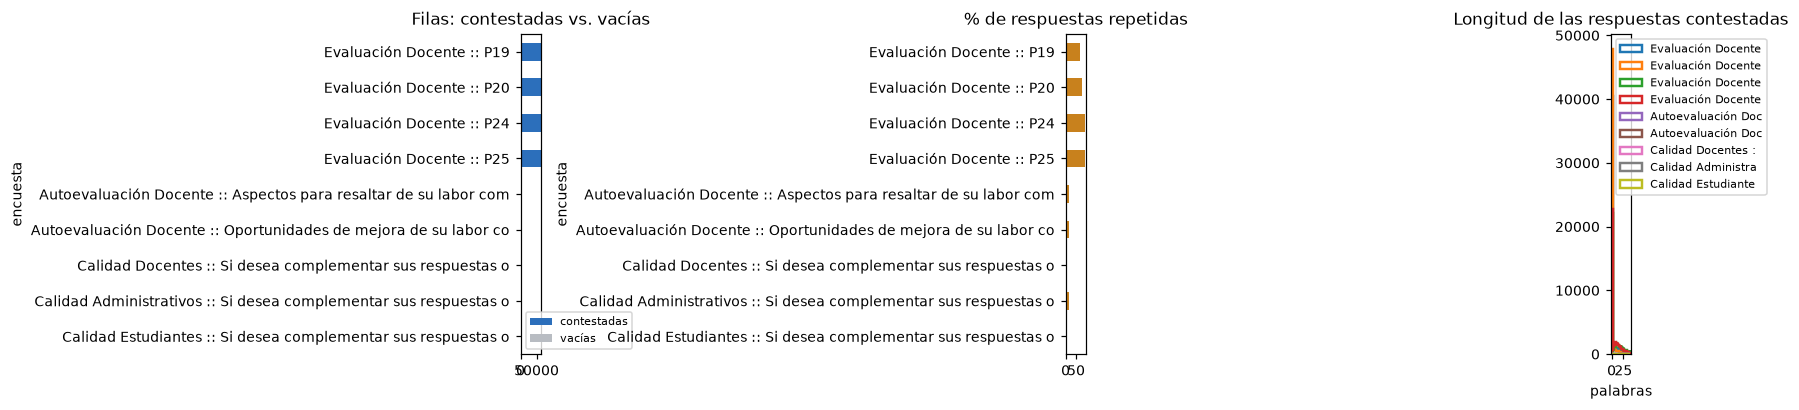

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

panorama[["contestadas"]].assign(
    vacías=panorama["filas"] - panorama["contestadas"]
).plot.barh(stacked=True, ax=ax[0], color=[AZUL, GRIS])
ax[0].set_title("Filas: contestadas vs. vacías"); ax[0].invert_yaxis()
ax[0].legend(fontsize=7)

panorama["duplicadas_%"].plot.barh(ax=ax[1], color=NARANJA)
ax[1].set_title("% de respuestas repetidas"); ax[1].invert_yaxis()

for nombre, e in encuestas.items():
    largos = [len(t.split()) for t in e.texto_clean if t.strip()]
    ax[2].hist(largos, bins=range(0, 41), histtype="step", lw=1.6, label=nombre[:18])
ax[2].set_title("Longitud de las respuestas contestadas")
ax[2].set_xlabel("palabras"); ax[2].legend(fontsize=7)

plt.tight_layout(); plt.show()

**Cómo leer estas tres gráficas.**

La primera responde la alarma del "65%": la barra gris no son datos perdidos,
son personas que no escribieron comentario. La azul es todo lo que el modelo
puede analizar.

La segunda explica por qué se deduplica: si media encuesta dice `"excelente"`,
ajustar sobre las repeticiones le da a HDBSCAN una densidad que no existe.

La tercera explica por qué BERTopic y no LDA: con esa mediana de palabras LDA
no tiene suficiente coocurrencia. El embedding trae el significado
precargado desde el preentrenamiento.

## Paso 3 — Higiene: a dónde va cada respuesta

**Qué hace:** clasifica cada fila en una de cuatro categorías.

**Por qué:** la versión anterior imprimía una sola cifra —"65,1%
descartados"— que mezclaba cosas incomparables:

| Categoría | Qué es | ¿Es una pérdida? |
|---|---|---|
| **VACÍA** | no contestó la pregunta abierta | **No.** Nunca hubo texto |
| **RUIDO** | contestó `"NR"`, `"n/a"`, `"-"` | No. No es opinión |
| **CORTA** | menos de 3 palabras: `"excelente"` | **Sí, parcialmente** |
| **MODELABLE** | entra al modelo | — |

Sólo la tercera es información real que el modelo de tópicos no puede
aprovechar. Y esas respuestas **sí entran en la rama de sentimiento**: una
polaridad sí se puede medir sobre `"excelente"`.

In [9]:
FOCAL = list(encuestas)[0]        # cambie por cualquier otra encuesta
encuesta = encuestas[FOCAL]

diagnostico = ModeladorTopicos(Config(), recursos)
validos, indices = diagnostico._higiene(encuesta.texto_clean)
h = diagnostico.higiene

print(f"\n{'='*64}\n  {FOCAL}\n{'='*64}")
print(f"  Filas en la hoja            {h['filas_totales']:>10,}")
print(f"  Vacías (no contestaron)     {h['vacias']:>10,}  ({h['pct_vacias']}%)")
print(f"  {'-'*60}")
print(f"  CONTESTADAS                 {h['contestadas']:>10,}  (tasa de respuesta {h['tasa_respuesta']}%)")
print(f"     · ruido ('NR','-','n/a') {h['ruido']:>10,}")
print(f"     · cortas (<3 palabras)   {h['cortas']:>10,}")
print(f"     · MODELABLES             {h['modelables']:>10,}  ({h['pct_modelables_de_contestadas']}% de las contestadas)")

00:37:23 | INFO    |   higiene: 64697 filas -> 0 vacías (0.0%, pregunta opcional) | 64697 contestadas: 39862 ruido, 2265 cortas, 22570 MODELABLES (34.9% de las contestadas)



  Evaluación Docente :: P19
  Filas en la hoja                64,697
  Vacías (no contestaron)              0  (0.0%)
  ------------------------------------------------------------
  CONTESTADAS                     64,697  (tasa de respuesta 100.0%)
     · ruido ('NR','-','n/a')     39,862
     · cortas (<3 palabras)        2,265
     · MODELABLES                 22,570  (34.89% de las contestadas)


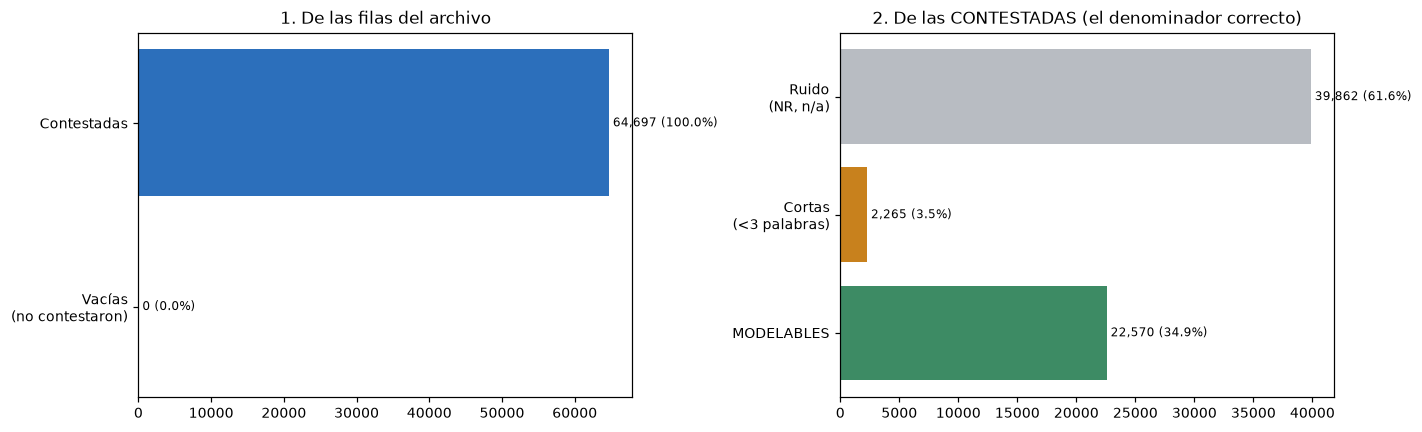

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].barh(["Vacías\n(no contestaron)", "Contestadas"],
           [h["vacias"], h["contestadas"]], color=[GRIS, AZUL])
ax[0].set_title("1. De las filas del archivo")
for i, v in enumerate([h["vacias"], h["contestadas"]]):
    ax[0].text(v, i, f" {v:,} ({100*v/h['filas_totales']:.1f}%)", va="center", fontsize=8)

partes = [h["modelables"], h["cortas"], h["ruido"]]
ax[1].barh(["MODELABLES", "Cortas\n(<3 palabras)", "Ruido\n(NR, n/a)"],
           partes, color=[VERDE, NARANJA, GRIS])
ax[1].set_title("2. De las CONTESTADAS (el denominador correcto)")
for i, v in enumerate(partes):
    ax[1].text(v, i, f" {v:,} ({100*v/h['contestadas']:.1f}%)", va="center", fontsize=8)

plt.tight_layout(); plt.show()

In [11]:
print("Ejemplos de respuestas descartadas por cortas:")
for t in h["ejemplos_cortas"][:15]:
    print(f"   · {t}")
print("\nEstas SÍ entran en la rama de sentimiento del Paso 11:")
print("una polaridad sí se puede medir sobre 'excelente', un tópico no.")

Ejemplos de respuestas descartadas por cortas:
   · excelente
   · todo perfecto
   · excelente profe
   · buen profesor
   · muy bueno
   · paciencia
   · paciencia
   · bien
   · le sabe
   · muy buena
   · buen profe
   · bien
   · su creatividad.
   · mucha paciencia
   · excelente profesora

Estas SÍ entran en la rama de sentimiento del Paso 11:
una polaridad sí se puede medir sobre 'excelente', un tópico no.


**Conclusión del paso.** El porcentaje que importa no es el 65% sobre filas,
sino el **porcentaje de respuestas contestadas que llega al modelo**. Ese es
el número que va al informe.

Si quisieras recuperar la franja de respuestas cortas para tópicos, la
palanca es `Config(min_tokens=2)`. El coste: tópicos construidos sobre
fragmentos de dos palabras, difíciles de interpretar.

## Paso 4 — Por qué salieron 136 tópicos

**Qué hace:** deduplica y traduce el hiperparámetro a su escala real.

**Por qué:** `min_topic_size` es un número absoluto, pero su efecto depende
por completo de cuántos documentos hay. La tabla traduce cada valor a "qué
porcentaje del corpus es" y "cuántos tópicos permite como máximo".

In [12]:
unicos, mapa, _ = ModeladorTopicos._deduplicar(validos)
N = len(unicos)
print(f"{len(validos):,} modelables -> {N:,} únicos ({100*(1-N/len(validos)):.1f}% de ahorro)\n")

tabla_escala = pd.DataFrame([
    {"min_topic_size": v, "% del corpus único": round(100 * v / N, 3),
     "techo de tópicos": N // v}
    for v in (25, 30, 50, 100, 200, 400, 800, 1600)
])
tabla_escala

22,570 modelables -> 19,989 únicos (11.4% de ahorro)



,min_topic_size,% del corpus único,techo de tópicos
0,25,0.125,799
1,30,0.150,666
2,50,0.250,399
3,100,0.500,199
4,200,1.001,99
5,400,2.001,49
6,800,4.002,24
7,1600,8.004,12


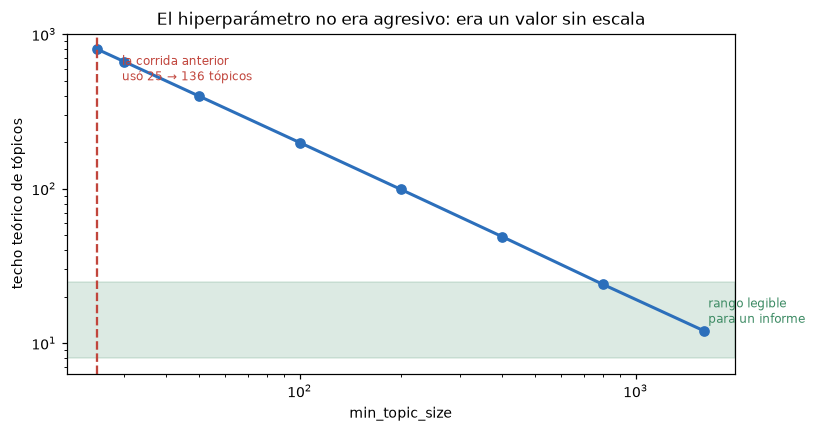

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tabla_escala["min_topic_size"], tabla_escala["techo de tópicos"],
        "o-", color=AZUL, lw=2)
ax.axhspan(8, 25, color=VERDE, alpha=0.18)
ax.text(tabla_escala["min_topic_size"].max(), 16,
        " rango legible\n para un informe", va="center", fontsize=8, color=VERDE)
ax.axvline(25, ls="--", color=ROJO)
ax.text(28, ax.get_ylim()[1]*0.6, "  la corrida anterior\n  usó 25 → 136 tópicos",
        fontsize=8, color=ROJO)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("min_topic_size"); ax.set_ylabel("techo teórico de tópicos")
ax.set_title("El hiperparámetro no era agresivo: era un valor sin escala")
plt.tight_layout(); plt.show()

**El segundo culpable: `min_samples`.** En HDBSCAN controla cuán conservador
es el algoritmo. Cuanto más alto respecto a `min_cluster_size`, más puntos
declara ruido. La corrida anterior usó un ratio de **0,40** cuando la
referencia práctica está cerca de **0,05**.

In [14]:
pd.DataFrame([
    {"min_cluster_size": a, "min_samples": b, "ratio": round(b/a, 2),
     "lectura": "muy conservador -> muchos outliers" if b/a > 0.20
                else "equilibrado" if b/a >= 0.03 else "permisivo -> pocos outliers"}
    for a, b in [(25,10),(25,15),(30,5),(30,10),(400,20),(400,40),(400,80)]
])

,min_cluster_size,min_samples,ratio,lectura
0,25,10,0.40,muy conservador -> muchos outliers
1,25,15,0.60,muy conservador -> muchos outliers
2,30,5,0.17,equilibrado
3,30,10,0.33,muy conservador -> muchos outliers
4,400,20,0.05,equilibrado
5,400,40,0.10,equilibrado
6,400,80,0.20,equilibrado


## Paso 5 — Embeddings

**Qué hace:** convierte cada respuesta única en un vector de 384 números.

**Por qué:** es lo que permite que dos frases sin palabras en común queden
cerca si significan lo mismo. Es la ventaja de BERTopic sobre LDA en textos
cortos.

**Para qué:** se calculan **una sola vez** y se guardan en caché. Sin esa
caché el grid search del Paso 6 sería inviable.

In [15]:
modelador_tmp = ModeladorTopicos(Config(nombre=FOCAL), recursos)
embeddings = modelador_tmp.codificar(unicos, "(tópicos)")
print(f"Matriz: {embeddings.shape[0]:,} documentos x {embeddings.shape[1]} dimensiones")

00:37:25 | INFO    |   embeddings (tópicos) recuperados de caché


Matriz: 19,989 documentos x 384 dimensiones


In [16]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer(Config().encoder)
pares = [
    ("la clase es muy magistral", "el profesor solo dicta catedra"),
    ("resuelve todas las dudas", "aclara las inquietudes de los estudiantes"),
    ("explica muy bien", "no explica nada bien"),
    ("llega puntual a clase", "el material de lectura es pertinente"),
]
v = encoder.encode([t for p in pares for t in p], normalize_embeddings=True)
print(f"{'frase A':<40} {'frase B':<44} similitud")
print("-" * 96)
for i, (a, b) in enumerate(pares):
    print(f"{a:<40} {b:<44} {float(v[2*i] @ v[2*i+1]):>6.3f}")

c:\Users\Acer\OneDrive\Escritorio\MINE009_Externado\CAPSTONE_U_EXTERNADO\capstonenlpencuestas_mine9\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


frase A                                  frase B                                      similitud
------------------------------------------------------------------------------------------------
la clase es muy magistral                el profesor solo dicta catedra                0.352
resuelve todas las dudas                 aclara las inquietudes de los estudiantes     0.474
explica muy bien                         no explica nada bien                          0.387
llega puntual a clase                    el material de lectura es pertinente          0.295


**Esta es la celda más importante del cuaderno para el informe.**

Las dos primeras filas casi no comparten palabras y quedan cerca: eso es lo
que BoW y TF-IDF no pueden hacer.

La tercera es la advertencia. El encoder ve **"explica muy bien"** y **"no
explica nada bien"** como muy parecidas, porque hablan del mismo tema. El
embedding captura el **aspecto**, no la **valoración**.

Por eso el sentimiento necesita su propia rama y su propio modelo: no se
puede deducir de la geometría del tópico. Es la justificación empírica de
toda la arquitectura de dos ramas.

## Paso 6 — Grid search: encontrar los hiperparámetros de la encuesta focal

**Qué hace:** prueba decenas de combinaciones de UMAP y HDBSCAN sobre UNA
encuesta y puntúa cada una contra criterios de negocio.

**Por qué no se optimiza coherencia:** un modelo de 2 tópicos gigantes puede
tener coherencia altísima y no decir nada. Lo que hace útil un modelo de
tópicos en un informe es que **quepa en una página y cubra el corpus**. Eso
es lo que se optimiza aquí, explícitamente.

**El truco que lo hace viable:** UMAP es lento (minutos sobre 20.000
documentos) y HDBSCAN es rápido (segundos). Un grid ingenuo recalcula UMAP en
cada combinación — por eso la corrida anterior tardaba más de un minuto por
punto. Aquí la proyección se calcula **una vez por configuración de UMAP** y
se reutiliza. Con 3 configuraciones de UMAP y 15 de HDBSCAN son 45 modelos
pero sólo **3 proyecciones**.

**Por qué este paso se repite luego para las otras 4 encuestas (Paso 13).**
Cada encuesta puede tener una estructura temática muy distinta: una centrada
en un tema puntual, otra cubriendo diez aspectos institucionales. Compartir
la fracción ganadora de esta encuesta con las demás asumiría que todas se
parecen. Aquí se explora a fondo sobre la focal para entender el
comportamiento; el Paso 13 repite la búsqueda, completa, para cada una.

In [17]:
criterios = CriteriosNegocio(
    n_topicos_min=8,            # menos, y el modelo no discrimina
    n_topicos_max=25,           # más, y nadie lo lee en una reunión
    pct_outliers_max=15.0,      # techo de opiniones sin clasificar
    pct_topico_mayor_max=40.0,  # ningún tópico debe tragarse el corpus
)
pd.Series(vars(criterios)).to_frame("valor")

,valor
n_topicos_min,8.00
n_topicos_max,25.00
pct_outliers_max,15.00
pct_topico_mayor_max,40.00
pct_top2_max,45.00
peso_topicos,0.25
peso_outliers,0.25
peso_equilibrio,0.25
peso_diversidad,0.15
peso_redundancia,0.10


In [ ]:
busqueda = GridSearchTopicos(Config(nombre=FOCAL), recursos).preparar(encuesta.texto_clean)
rejilla_umap, rejilla_hdbscan = busqueda.rejilla_sugerida(criterios)

print("Rejilla UMAP:")
for r in rejilla_umap:
    print("   ", r)
print(f"\nRejilla HDBSCAN ({len(rejilla_hdbscan)} combinaciones):")
print("   min_topic_size:", sorted({r['min_topic_size'] for r in rejilla_hdbscan}))
print("   ratio_min_samples:", sorted({r['ratio_min_samples'] for r in rejilla_hdbscan}))
print(f"\nTOTAL: {len(rejilla_umap) * len(rejilla_hdbscan)} modelos, "
      f"{len(rejilla_umap)} proyecciones UMAP")

00:37:46 | INFO    |   higiene: 64697 filas -> 0 vacías (0.0%, pregunta opcional) | 64697 contestadas: 39862 ruido, 2265 cortas, 22570 MODELABLES (34.9% de las contestadas)
00:37:47 | INFO    |   embeddings (grid search) recuperados de caché
00:37:47 | INFO    | Grid preparado: 19989 documentos únicos, embeddings (19989, 384)
00:37:47 | INFO    | Rejilla sugerida para 19989 documentos: min_topic_size [266, 466, 815, 1427, 2498] x 3 ratios x 3 UMAP = 60 combinaciones


Rejilla UMAP:
    {'n_neighbors': 15, 'n_components': 5}
    {'n_neighbors': 30, 'n_components': 5}
    {'n_neighbors': 50, 'n_components': 5}

Rejilla HDBSCAN (20 combinaciones):
   min_topic_size: [266, 466, 815, 1427, 2498]
   ratio_min_samples: [0.02, 0.05]

TOTAL: 60 modelos, 3 proyecciones UMAP


: 

**Los valores no están elegidos a ojo.** Se derivan del objetivo: si se
quieren entre 8 y 25 tópicos sobre N documentos, el tamaño mínimo útil va de
aproximadamente N/(3·25) hasta N/8. El módulo hace esa cuenta y reparte cinco
valores en escala geométrica.

La celda siguiente tarda varios minutos. Cada línea del log es una
combinación, y marca **CUMPLE** las que pasan los criterios.

In [ ]:
tabla_grid = busqueda.ejecutar(rejilla_umap, rejilla_hdbscan, criterios=criterios)

00:38:04 | INFO    | UMAP n_neighbors=15 n_components=5 — proyectando 19989 docs (esta es la parte lenta, se hace una sola vez)...
00:39:32 | INFO    |   [ 1/60] mts= 266 ms=  5 ->   2 tópicos |   0.8% outliers | mayor 95.1% | puntaje 0.540
00:39:41 | INFO    |   [ 2/60] mts= 266 ms=  5 ->  16 tópicos |  44.2% outliers | mayor  6.7% | puntaje 0.524
00:39:48 | INFO    |   [ 3/60] mts= 266 ms= 13 ->   2 tópicos |   0.8% outliers | mayor 95.1% | puntaje 0.540
00:39:57 | INFO    |   [ 4/60] mts= 266 ms= 13 ->  14 tópicos |  51.5% outliers | mayor  6.8% | puntaje 0.489
00:40:03 | INFO    |   [ 5/60] mts= 466 ms=  9 ->   2 tópicos |   0.8% outliers | mayor 95.1% | puntaje 0.540
00:40:11 | INFO    |   [ 6/60] mts= 466 ms=  9 ->  10 tópicos |  46.2% outliers | mayor  8.4% | puntaje 0.503
00:40:18 | INFO    |   [ 7/60] mts= 466 ms= 23 ->   2 tópicos |   0.8% outliers | mayor 95.1% | puntaje 0.540
00:40:25 | INFO    |   [ 8/60] mts= 466 ms= 23 ->   9 tópicos |  44.5% outliers | mayor 16.2% | pun

In [ ]:
COLS = ["n_neighbors", "min_topic_size", "min_samples", "ratio_ms", "metodo",
        "n_topicos", "pct_outliers", "pct_top1", "pct_top2", "gini",
        "diversidad", "pares_redundantes", "puntaje", "cumple"]
print("=== MEJORES 12 COMBINACIONES ===")
tabla_grid[COLS].head(12)

In [ ]:
print("=== PEORES 5 (para ver el contraste) ===")
tabla_grid[COLS].tail(5)

**Cómo leer el puntaje.** Cada componente es auditable por separado, de modo
que la elección del modelo no es una caja negra:

- `p_topicos` — ¿cae el número de tópicos en el rango legible?
- `p_outliers` — ¿está la tasa de outliers bajo el techo?
- `p_equilibrio` — ¿hay algún tópico que se traga el corpus?
- `p_diversidad` — ¿los tópicos se describen con palabras distintas?
- `p_redundancia` — ¿hay pares de tópicos casi idénticos?

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

for cumple, marca, color, etiqueta in [(0, "o", GRIS, "no cumple"),
                                       (1, "*", VERDE, "cumple")]:
    sub = tabla_grid[tabla_grid["cumple"] == cumple]
    ax[0].scatter(sub["n_topicos"], sub["pct_outliers"], marker=marca,
                  s=150 if cumple else 45, c=color, alpha=0.9,
                  edgecolor="black", lw=0.5, label=etiqueta)
ax[0].axhline(criterios.pct_outliers_max, ls="--", c=ROJO, lw=1)
ax[0].axvspan(criterios.n_topicos_min, criterios.n_topicos_max, color=VERDE, alpha=0.12)
ax[0].set_xlabel("nº de tópicos"); ax[0].set_ylabel("% outliers")
ax[0].set_title("Todo el espacio explorado"); ax[0].legend(fontsize=8)

for vecinos, color in zip(sorted(tabla_grid["n_neighbors"].unique()),
                          [AZUL, NARANJA, MORADO]):
    sub = tabla_grid[tabla_grid["n_neighbors"] == vecinos]
    agg = sub.groupby("min_topic_size")["n_topicos"].mean()
    ax[1].plot(agg.index, agg.values, "o-", color=color, label=f"n_neighbors={vecinos}")
ax[1].axhspan(criterios.n_topicos_min, criterios.n_topicos_max, color=VERDE, alpha=0.12)
ax[1].set_xscale("log"); ax[1].set_xlabel("min_topic_size")
ax[1].set_ylabel("nº de tópicos"); ax[1].set_title("Efecto de min_topic_size")
ax[1].legend(fontsize=8)

agg = tabla_grid.groupby("ratio_ms")["pct_outliers"].mean()
ax[2].plot(agg.index, agg.values, "s-", color=ROJO)
ax[2].axhline(criterios.pct_outliers_max, ls="--", c=GRIS, lw=1)
ax[2].set_xlabel("ratio min_samples / min_topic_size")
ax[2].set_ylabel("% outliers medio")
ax[2].set_title("Por qué la corrida anterior tenía 40% de outliers")

plt.tight_layout(); plt.show()

**Las dos gráficas de la derecha son el diagnóstico completo del problema
original, medido sobre tus propios datos:** el número de tópicos lo gobierna
`min_topic_size`, y la tasa de outliers la gobierna el ratio de
`min_samples`. Ninguno de los dos estaba calibrado.

In [ ]:
# El módulo propone la mejor combinación, pero la decisión es editorial:
# un modelo de 10 tópicos gruesos y otro de 22 finos pueden ser ambos válidos.
SELECCION = 0        # cambie el índice para tomar otra fila de la tabla
cfg_final = busqueda.mejor_config(indice=SELECCION)

print("Configuración elegida:")
for campo in ("umap_n_neighbors", "umap_n_components", "min_topic_size", "min_samples"):
    print(f"   {campo:<22} {getattr(cfg_final, campo)}")
cfg_final.nombre = FOCAL
cfg_final.output_dir = RAIZ / "outputs" / "mvp"

## Paso 7 — El modelo final

**Qué hace:** entrena con la configuración ganadora y aplica la cascada de
recuperación de outliers.

**Por qué una cascada:** `c-tf-idf` compara el vector disperso de la respuesta
contra el del tópico. En respuestas de seis palabras ese solapamiento es casi
nulo, y por eso la corrida anterior sólo recuperaba un 5% de los outliers.
`embeddings` compara vectores densos y recupera mucho más. La cascada prueba
las tres en orden y cada una ataca lo que dejó la anterior.

**Ojo con el umbral.** `umbral_outliers=0` reasignaría **todo** al tópico más
cercano, encaje o no, dejando 0% de outliers. Eso no es un logro: es
asignación forzada. El valor por defecto es 0,20.

In [ ]:
modelador = ModeladorTopicos(cfg_final, recursos)
modelador.entrenar(encuesta.texto_clean)

In [ ]:
metricas = modelador.metricas()
pd.DataFrame({
    "corrida anterior": {
        "min_topic_size": 25, "min_samples": 10, "ratio min_samples": 0.40,
        "n_topicos": 136, "pct_outliers": 40.1,
        "reducción de outliers": "8.882 -> 8.433 (5%)",
    },
    "MVP 2": {
        "min_topic_size": metricas["min_topic_size"],
        "min_samples": metricas["min_samples"],
        "ratio min_samples": round(metricas["min_samples"]/metricas["min_topic_size"], 2),
        "n_topicos": metricas["n_topicos"], "pct_outliers": metricas["pct_outliers"],
        "reducción de outliers": "ver log de la celda anterior",
    },
})

In [ ]:
arr = np.asarray(modelador.topicos)
n_exc, n_out = int((arr == EXCLUIDO).sum()), int((arr == OUTLIER).sum())
n_asig = int((arr >= 0).sum())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].barh(["Clasificadas en un tópico", "Outliers (-1)",
            "Fuera del modelo (-2)\nvacías · ruido · cortas"],
           [n_asig, n_out, n_exc], color=[VERDE, NARANJA, GRIS])
ax[0].set_title("Destino de cada fila del archivo")
for i, v in enumerate([n_asig, n_out, n_exc]):
    ax[0].text(v, i, f" {v:,}", va="center", fontsize=8)

pd.Series(arr[arr >= 0]).value_counts().sort_values().plot.barh(ax=ax[1], color=AZUL)
ax[1].set_title(f"Tamaño de cada tópico ({metricas['n_topicos']} tópicos)")
ax[1].set_xlabel("respuestas")
plt.tight_layout(); plt.show()
print(f"Outliers sobre lo MODELADO: {100*n_out/max(n_asig+n_out,1):.1f}%")
print(f"Concentración: top1 {metricas['pct_top1']}% | top2 {metricas['pct_top2']}% "
      f"| Gini {metricas['gini']}")
print(f"Crecimiento máximo de un tópico por la cascada: "
      f"{metricas['crecimiento_max_cascada']:+.1f}%")

In [ ]:
# ¿Cuánto creció cada tópico por la reasignación de outliers?
# Sin tope, un tópico llegó a crecer +154% sobre el corpus real: la cascada
# convertía los tópicos grandes en imanes y concentraba toda la masa.
crecimiento = pd.Series(modelador.crecimiento_cascada).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, max(3, 0.32 * len(crecimiento))))
crecimiento.plot.barh(ax=ax, color=[ROJO if v > 50 else AZUL for v in crecimiento])
ax.axvline(100 * cfg_final.tope_crecimiento_cascada, ls="--", c=ROJO, lw=1)
ax.set_xlabel("% de crecimiento por la cascada")
ax.set_title("Crecimiento de cada tópico (línea roja = tope configurado)")
plt.tight_layout(); plt.show()

**El denominador importa.** El porcentaje de outliers se calcula sobre lo que
efectivamente entró al modelo, no sobre las filas del archivo. Sumar las
vacías al denominador hace parecer que el modelo funciona mejor de lo que
funciona.

## Paso 8 — Dónde entran las stopwords

**Qué hace:** compara los términos de un mismo tópico con y sin la lista de
stopwords.

**Por qué esta celda existe:** para demostrar, y no sólo afirmar, que las
stopwords se aplican **después** de la clusterización. Los documentos son
exactamente los mismos en ambas columnas — sólo cambia la etiqueta. Ese es
todo el argumento: se gana legibilidad sin tocar la agrupación.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

TOPICO_DEMO = int(pd.Series(arr[arr >= 0]).value_counts().index[0])
docs_topico = [d for d, t in zip(modelador.docs_modelo, modelador.modelo.topics_)
               if t == TOPICO_DEMO]
agregado = [" ".join(docs_topico)]   # así lo ve c-TF-IDF: uno por tópico


def terminos(stopwords):
    vec = CountVectorizer(stop_words=stopwords, ngram_range=(1, 2), min_df=1,
                          max_df=1.0, token_pattern=modelador.token_pattern)
    conteos = np.asarray(vec.fit_transform(agregado).todense()).ravel()
    return np.array(vec.get_feature_names_out())[np.argsort(-conteos)][:12].tolist()


print(f"Tópico {TOPICO_DEMO} — {len(docs_topico):,} respuestas únicas\n")
pd.DataFrame({
    "SIN stopwords": terminos(None),
    "CON stopwords (lo que usa el modelo)": terminos(
        recursos.stopwords_para_vectorizador(modelador.token_pattern)),
})

## Paso 9 — Los tópicos descubiertos

**Qué hace:** presenta los tópicos con sus términos, su tamaño y las
respuestas más representativas.

**Cómo leer las dos columnas de tamaño:** `Count` cuenta documentos
**únicos**; `Respuestas` cuenta respuestas reales del corpus. Tras deduplicar
ambas difieren, y la prevalencia que va al informe es la segunda.

In [ ]:
tabla = modelador.tabla_topicos()
tabla

In [ ]:
modelador.modelo.visualize_barchart(top_n_topics=min(12, len(tabla)), n_words=8, height=280)

In [ ]:
modelador.modelo.visualize_topics()     # mapa de distancia intertópica

In [ ]:
modelador.modelo.visualize_hierarchy()  # qué tópicos son primos entre sí

In [ ]:
modelador.modelo.visualize_heatmap()    # matriz de similitud tópico a tópico

**Para qué sirven el dendrograma y el heatmap.** Si dos tópicos aparecen a
distancia casi cero, el modelo los separó pero significan lo mismo. La celda
siguiente los lista; si hay varios, conviene fusionarlos con
`Config(nr_topics="auto")`.

In [ ]:
redundantes = modelador.redundancia(umbral=0.20)
print(f"Pares de tópicos a distancia <= 0,20: {len(redundantes)}")
redundantes.head(10) if len(redundantes) else "Sin redundancia relevante."

In [ ]:
for topico in tabla.head(8)["Topic"]:
    terminos_top = tabla.loc[tabla["Topic"] == topico, "Terminos"].iloc[0]
    n = int(tabla.loc[tabla["Topic"] == topico, "Respuestas"].iloc[0])
    print(f"\n{'='*96}\nTÓPICO {topico}  ({n:,} respuestas)  |  {terminos_top}\n{'='*96}")
    for ejemplo in (modelador.modelo.get_representative_docs(topico) or [])[:3]:
        print(f"   · {ejemplo[:110]}")

## Paso 10 — Segmentación en cláusulas

**Cambia la rama.** A partir de aquí se usa el **texto original, con tildes y
con stopwords**. Nada de la rama de tópicos toca este texto.

**Qué hace:** parte cada respuesta en unidades de opinión independientes.

**Por qué:** `"explica bien pero nunca responde correos"` tiene una valoración
positiva y una negativa sobre dos aspectos distintos. Darle una sola
polaridad sería falso en la mitad del texto.

**De dónde salen los cortes:** de `negaciones.xlsx`, tipo `ADVERSATIVO`.

In [ ]:
segmentador = Segmentador(cfg_final, recursos)
adversativos = recursos.terminos_por_tipo("ADVERSATIVO")
print(f"Conectores de corte: {adversativos}\n")

candidatas = [t for t in encuesta.texto_original
              if len(t.split()) > 10 and any(f" {a} " in t.lower() for a in adversativos)]
for texto in candidatas[:5]:
    print(f"\nRESPUESTA: {texto[:155]}")
    for i, c in enumerate(segmentador.segmentar(texto), 1):
        print(f"   cláusula {i}: {c[:110]}")

In [ ]:
clausulas = segmentador.segmentar_corpus(encuesta.texto_original)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
clausulas.groupby("doc_id").size().value_counts().sort_index().plot.bar(ax=ax[0], color=AZUL)
ax[0].set_title("Cláusulas por respuesta"); ax[0].set_xlabel("nº de cláusulas")
ax[1].hist(clausulas["clausula"].str.split().str.len(), bins=range(0, 41), color=MORADO)
ax[1].set_title("Longitud de las cláusulas"); ax[1].set_xlabel("palabras")
plt.tight_layout(); plt.show()
print(f"{len(clausulas):,} cláusulas extraídas")

## Paso 11 — Sentimiento

**Qué hace:** clasifica cada cláusula como POS, NEU o NEG con
`robertuito-sentiment-analysis`, de la familia RoBERTa, entrenado en español.

**Para qué sirve la tercera gráfica:** es un control de calidad, no un
resultado. Si las cláusulas marcadas NEG **no** contienen más negadores que
las POS, algo va mal en la clasificación.

In [ ]:
analizador = AnalizadorSentimiento(cfg_final, recursos)
clausulas = pd.concat([
    clausulas.reset_index(drop=True),
    analizador.clasificar(clausulas["clausula"].tolist()),
    analizador.marcar_negacion(clausulas["clausula"].tolist()),
], axis=1)
clausulas.head(10)

In [ ]:
dist = clausulas["sentimiento"].value_counts()
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

ax[0].pie(dist, labels=dist.index, autopct="%1.1f%%", startangle=90,
          colors=[COLOR_SENT[s] for s in dist.index])
ax[0].set_title("Polaridad global de las cláusulas")

for etiqueta in [POS, NEU, NEG]:
    ax[1].hist(clausulas[clausulas["sentimiento"] == etiqueta]["confianza"],
               bins=25, histtype="step", lw=1.8, color=COLOR_SENT[etiqueta], label=etiqueta)
ax[1].set_title("Confianza del modelo"); ax[1].set_xlabel("score"); ax[1].legend()

con_neg = clausulas.groupby("sentimiento")["tiene_negador"].mean() * 100
con_neg.plot.bar(ax=ax[2], color=[COLOR_SENT[s] for s in con_neg.index])
ax[2].set_title("% de cláusulas con negador explícito"); ax[2].set_ylabel("%")
plt.tight_layout(); plt.show()

In [ ]:
sospechosas = clausulas[(clausulas["tiene_negador"]) &
                        (clausulas["sentimiento"] == POS) &
                        (clausulas["confianza"] > 0.85)]
print(f"Cláusulas con negador clasificadas POS con confianza > 0,85: "
      f"{len(sospechosas):,} ({100*len(sospechosas)/len(clausulas):.2f}%)\n")
for t in sospechosas["clausula"].head(8):
    print(f"   · {t[:110]}")

### 11b — Validación externa: la nota numérica

**Qué hace:** contrasta la polaridad detectada contra la calificación de 1 a 5
que la misma persona dio en el mismo formulario.

**Por qué importa:** es la única evidencia externa disponible sin etiquetado
manual. La nota es independiente del texto, así que si el modelo de
sentimiento funciona en este dominio, las cláusulas NEG deben concentrarse en
notas bajas y las POS en notas altas.

**Lo que NO valida:** los tópicos. Para eso no hay atajo: hace falta
anotación humana. Pero deja la rama de sentimiento con respaldo
reproducible, que es más de lo que tenía.

**Cómo leerlo:** `separacion_POS_menos_NEG` es la cifra principal. Un valor
positivo y grande significa que el modelo separa. El `spearman_rho` mide lo
mismo de forma continua; `kruskal_p` dice si la diferencia entre los tres
grupos es estadísticamente significativa.

In [ ]:
notas = pd.to_numeric(encuesta.marco[COLUMNA_VALIDACION], errors="coerce")
validacion = validar_contra_nota(clausulas, notas.tolist())

detalle = validacion.pop("detalle", None)
display(pd.Series(validacion).to_frame("valor"))
if detalle is not None:
    display(detalle)

In [ ]:
if detalle is not None:
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))

    orden_pol = [p for p in (NEG, NEU, POS) if p in detalle.index]
    ax[0].bar(orden_pol, [detalle.loc[p, "mean"] for p in orden_pol],
              color=[COLOR_SENT[p] for p in orden_pol])
    ax[0].set_ylim(1, 5); ax[0].set_ylabel("nota media (1-5)")
    ax[0].set_title("Nota media según la polaridad detectada")

    for p in orden_pol:
        sub = clausulas[clausulas["sentimiento"] == p]["doc_id"].map(notas).dropna()
        ax[1].hist(sub, bins=np.arange(1, 5.25, 0.25), histtype="step", lw=1.8,
                   density=True, color=COLOR_SENT[p], label=p)
    ax[1].set_xlabel("nota general"); ax[1].legend()
    ax[1].set_title("Distribución de la nota por polaridad")
    plt.tight_layout(); plt.show()

## Paso 12 — ABSA: el cruce

**Qué hace:** proyecta cada cláusula al modelo de tópicos ya entrenado y cruza
el aspecto con la polaridad.

**Por qué no se reentrena nada:** las cláusulas no estaban en el
entrenamiento, pero se codifican con el mismo encoder y se le pregunta al
modelo a qué tópico pertenecen. Esa es la parte *aspect-based* de ABSA.

**Para qué:** para responder lo que ninguna rama puede contestar sola — **¿de
qué aspecto concreto se habla mal?**

In [ ]:
from Mod_Bertopic import _normalizar_minimo

# Las cláusulas se normalizan al espacio de la rama de tópicos SÓLO para poder
# proyectarlas. El sentimiento ya se calculó antes, sobre el texto original.
clausulas_clean = [_normalizar_minimo(c, recursos) for c in clausulas["clausula"]]
emb_clausulas = modelador.codificar(clausulas_clean, "(cláusulas)")
clausulas["topico"] = modelador.asignar(clausulas_clean, emb_clausulas)

asignadas = int((clausulas["topico"] >= 0).sum())
print(f"Cláusulas asignadas a un tópico: {asignadas:,} de {len(clausulas):,} "
      f"({100*asignadas/len(clausulas):.1f}%)")

In [ ]:
absa = construir_absa(clausulas, tabla)
absa[["total_clausulas", "pct_positivo", "pct_neutro", "pct_negativo",
      "polaridad_neta", "prioridad", "terminos"]]

In [ ]:
COLUMNA = {POS: "pct_positivo", NEU: "pct_neutro", NEG: "pct_negativo"}
orden = absa.sort_values("polaridad_neta")
etiquetas = [f"{t} · {str(orden.loc[t, 'terminos'])[:42]}" for t in orden.index]

fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(orden))))
izq = np.zeros(len(orden))
for etiqueta in [NEG, NEU, POS]:
    valores = orden[COLUMNA[etiqueta]].to_numpy()
    ax.barh(etiquetas, valores, left=izq, color=COLOR_SENT[etiqueta], label=etiqueta)
    izq = izq + valores
ax.set_xlim(0, 100); ax.set_xlabel("% de cláusulas")
ax.set_title(f"{FOCAL} — composición de polaridad por aspecto")
ax.legend(ncol=3, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6.5))
x, y = absa["total_clausulas"], absa["pct_negativo"]
ax.scatter(x, y, s=x / x.max() * 520 + 50, c=absa["polaridad_neta"],
           cmap="RdYlGn", edgecolor="black", lw=0.6, alpha=0.92)
ax.axvline(x.median(), ls="--", c="gray", lw=1)
ax.axhline(y.median(), ls="--", c="gray", lw=1)
for t in absa.index:
    ax.annotate(str(t), (x[t], y[t]), fontsize=8, ha="center", va="center", weight="bold")
ax.text(0.98, 0.97, "URGENTE\nmucho volumen · mucha negatividad", transform=ax.transAxes,
        ha="right", va="top", fontsize=8, color=ROJO, weight="bold")
ax.text(0.02, 0.97, "VIGILAR\npoco volumen · mucha negatividad", transform=ax.transAxes,
        ha="left", va="top", fontsize=8, color=NARANJA)
ax.text(0.98, 0.03, "FORTALEZA\nmucho volumen · poca negatividad", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, color=VERDE, weight="bold")
ax.set_xlabel("Volumen — cláusulas que mencionan el aspecto")
ax.set_ylabel("% de cláusulas negativas")
ax.set_title(f"{FOCAL} — matriz de priorización de aspectos")
plt.tight_layout(); plt.show()
print("Los números son IDs de tópico; sus términos están en la tabla anterior.")

**Esta gráfica es el entregable del proyecto.** Sin el cruce, un aspecto con
mucho volumen y mucha negatividad y otro con poco volumen y mucha negatividad
se ven idénticos en una lista de frecuencias. Aquí uno es una urgencia
institucional y el otro un caso puntual.

In [ ]:
print("=" * 100)
print("LOS 5 ASPECTOS DE MAYOR PRIORIDAD, CON SUS CLÁUSULAS REALES")
print("=" * 100)
for topico in absa.head(5).index:
    fila = absa.loc[topico]
    print(f"\n▸ TÓPICO {topico}  |  {fila['terminos']}")
    print(f"  {int(fila['total_clausulas']):,} cláusulas · {fila['pct_negativo']}% negativas "
          f"· polaridad neta {fila['polaridad_neta']:+.3f}")
    print("  NEGATIVAS:")
    for t in ejemplos_por_topico(clausulas, topico, NEG, 3):
        print(f"     - {t[:105]}")
    print("  POSITIVAS:")
    for t in ejemplos_por_topico(clausulas, topico, POS, 2):
        print(f"     + {t[:105]}")

## Paso 13 — Las 5 encuestas, cada una con su propio grid search

**Qué hace:** repite el Paso 6 — completo, con su propia búsqueda de UMAP y
HDBSCAN — de forma **independiente para cada una de las 5 encuestas**, y
luego entrena los cinco modelos finales con los hiperparámetros que ganó
cada una.

**Por qué no se reutiliza la config de la encuesta focal.** Una fracción de
corpus que da 20 tópicos limpios en una encuesta puede dar 2 o 40 en otra, si
su estructura temática es distinta. La alternativa barata —una sola fracción
compartida— fue justamente lo que se descartó al revisar el Paso 6: resolvía
la escala del hiperparámetro pero no la variación entre encuestas.

**Costo:** son 5 búsquedas completas en vez de una, así que este paso tarda
proporcionalmente más. Es el precio de que cada encuesta reciba el modelo que
realmente le conviene.

In [ ]:
cargadas_todas = cargar_encuestas(RUTA_CORPUS, recursos)

cfg_base = Config(
    umap_n_neighbors=cfg_final.umap_n_neighbors,  # se reutiliza como punto de partida;
    umap_n_components=cfg_final.umap_n_components,  # el grid explora igual sus propios valores
    output_dir=RAIZ / "outputs" / "mvp",
)

configs_por_encuesta = buscar_config_por_encuesta(
    cargadas_todas, cfg_base, recursos, criterios=criterios
)

In [ ]:
print("Hiperparámetros ganadores, uno por encuesta:\n")
for nombre, c in configs_por_encuesta.items():
    print(f"  {nombre:<26} min_topic_size={c.min_topic_size:>4}  "
          f"min_samples={c.min_samples:>3}  n_neighbors={c.umap_n_neighbors:>2}")
print("\nSi todos los valores fueran idénticos, no habría hecho falta repetir la")
print("búsqueda. Cuando difieren, es la evidencia de que cada encuesta sí necesita")
print("su propia calibración.")

In [ ]:
resultados = ejecutar_pipeline(
    cfg=cfg_base,                              # respaldo si alguna encuesta falla
    configs_por_encuesta=configs_por_encuesta, # config propia para cada una
)

In [ ]:
comparativa = resumen_comparativo(resultados)
comparativa

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

comparativa["n_topicos"].plot.barh(ax=ax[0, 0], color=AZUL)
ax[0, 0].set_title("Tópicos por encuesta"); ax[0, 0].invert_yaxis()

comparativa["pct_outliers"].plot.barh(ax=ax[0, 1], color=NARANJA)
ax[0, 1].axvline(15, ls="--", c=ROJO); ax[0, 1].invert_yaxis()
ax[0, 1].set_title("% outliers (línea roja = techo aceptado)")

comparativa[["pct_positivo", "pct_neutro", "pct_negativo"]].plot.barh(
    stacked=True, ax=ax[1, 0], color=[VERDE, "#9aa0a6", ROJO])
ax[1, 0].set_title("Composición de polaridad"); ax[1, 0].invert_yaxis()
ax[1, 0].legend(fontsize=7, loc="lower right")

comparativa["tasa_respuesta"].plot.barh(ax=ax[1, 1], color=MORADO)
ax[1, 1].set_title("Tasa de respuesta a la pregunta abierta (%)")
ax[1, 1].invert_yaxis()

plt.tight_layout(); plt.show()

In [ ]:
for nombre, r in resultados.items():
    if r.absa.empty:
        continue
    print(f"\n{'='*100}\n{nombre.upper()} — 3 aspectos más críticos\n{'='*100}")
    print(r.absa.head(3)[["total_clausulas", "pct_negativo", "polaridad_neta",
                          "terminos"]].to_string())

## Paso 14 — Exportación

In [ ]:
SALIDA = RAIZ / "outputs" / "mvp"
SALIDA.mkdir(parents=True, exist_ok=True)

for nombre, r in resultados.items():
    slug = (nombre.lower().replace(" ", "_")
            .replace("ó", "o").replace("á", "a").replace("í", "i"))
    destino = SALIDA / slug
    destino.mkdir(exist_ok=True)
    r.topicos.to_csv(destino / "topicos.csv", index=False)
    r.clausulas.to_csv(destino / "clausulas_sentimiento.csv", index=False)
    r.absa.to_csv(destino / "absa.csv")
    print(f"  {nombre:<28} -> {destino.relative_to(RAIZ)}")

with pd.ExcelWriter(SALIDA / "ABSA_todas_las_encuestas.xlsx") as escritor:
    comparativa.to_excel(escritor, sheet_name="resumen")
    tabla_grid.to_excel(escritor, sheet_name="grid_search", index=False)
    for nombre, r in resultados.items():
        if not r.absa.empty:
            r.absa.to_excel(escritor, sheet_name=nombre[:28])
print(f"\nExcel consolidado: {(SALIDA / 'ABSA_todas_las_encuestas.xlsx').relative_to(RAIZ)}")

## Paso 15 — Conclusiones

### Sobre el "65% de corpus perdido"

**No hubo pérdida.** La pregunta abierta es opcional y la mayoría de las filas
son celdas vacías. El número que debe ir al informe no es el 65% sobre filas,
sino el porcentaje de **respuestas contestadas** que llega al modelo, que es
mucho más alto. La tasa de respuesta es un dato del instrumento, no un
defecto del pipeline — y es interesante por sí misma.

La única pérdida real son las respuestas de menos de tres palabras. Y ni
siquiera se pierden del todo: entran en la rama de sentimiento, porque una
polaridad sí se puede medir sobre `"excelente"` aunque un tópico no.

### Sobre los 136 tópicos y el 40% de outliers

Fueron dos errores de calibración, no un fallo de BERTopic:

1. `min_topic_size=25` sobre ~20.000 documentos era el **0,125% del corpus**.
   El número absoluto no dice nada sin la escala del corpus.
2. `min_samples=10` con `min_cluster_size=25` da un ratio de **0,40**, cuando
   la referencia práctica está cerca de 0,05. HDBSCAN se vuelve tan
   conservador que declara ruido a cuatro de cada diez documentos.

A eso se sumó que la reducción de outliers usaba sólo `c-tf-idf`, casi inútil
en respuestas de seis palabras. La cascada con `embeddings` recupera un orden
de magnitud más.

### Sobre el método

La decisión de hiperparámetros ya no es una corazonada. El grid search
explora el espacio y puntúa cada combinación contra criterios explícitos —
número de tópicos legible, techo de outliers, equilibrio, diversidad,
redundancia — y cada componente del puntaje es auditable por separado.

Deliberadamente **no se optimiza coherencia**: un modelo de dos tópicos
gigantes puede tener coherencia altísima y no servir para nada.

---

## Recomendaciones

**1. Ajustar `CriteriosNegocio` a lo que necesita el informe, no al revés.**
Si el jurado espera un análisis fino, sube `n_topicos_max` a 30 y vuelve a
correr el Paso 6.

**2. No celebrar 0% de outliers.** Con `umbral_outliers=0` todo documento
acaba en algún tópico, encaje o no. Un 5–12% de outliers es señal de un
modelo honesto, no de uno defectuoso.

**3. Revisar manualmente los tópicos antes de nombrarlos.** El Paso 9 imprime
las respuestas representativas precisamente para eso. Un tópico cuyos
términos no se dejan resumir en una etiqueta clara es candidato a fusión con
`Config(nr_topics="auto")`.

**4. Validar el sentimiento contra tu etiquetado manual.** `robertuito` se
entrenó con tuits, no con encuestas académicas. Antes de citar sus
porcentajes hay que medirlo contra `Punto20` y `Punto24` y reportar el F1 por
clase. La clase NEU será la más débil: es la que los anotadores humanos
marcan de forma más inconsistente.

**5. Reportar siempre los dos denominadores.** Outliers sobre lo modelado, y
respuestas modelables sobre las contestadas. Mezclarlos es la forma más
rápida de que una cifra parezca mucho mejor o mucho peor de lo que es.

**6. Siguiente ciclo: medir los tópicos contra las etiquetas manuales.** Con
etiquetas humanas disponibles, la evaluación deja de depender de métricas
estructurales y pasa a ser pureza, ARI y NMI. Eso es lo que hace el resultado
defendible ante un jurado, y convierte este MVP en un capstone.

### Limitaciones que hay que declarar

- La segmentación en cláusulas es heurística: corta por puntuación y por
  conectores adversativos. Funciona en el caso frecuente y falla en
  construcciones complejas.
- La deduplicación cambia el peso de los tópicos. Para prevalencia, la cifra
  correcta es `Respuestas`, no `Count`.
- El grid search explora un espacio acotado. Si ninguna combinación cumple
  los criterios, el módulo lo dice explícitamente en vez de fingir un
  ganador.